In [1]:
import os
import sys
import subprocess
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # Zmiana na wersję notebookową
import random
import tarfile
import urllib.request
from transformers import AutoImageProcessor, AutoModel

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 45390
DATA_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz"
DATA_DIR = "imagenette2-320"
REPO_NAME = "ssl-data-curation"
DINO_MODEL = "facebook/dinov2-large"
NUM_CLASSES = 10

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
print(f"Używane urządzenie: {device}")

Używane urządzenie: cuda


In [2]:
if not os.path.exists(DATA_DIR):
    print("--- Pobieranie zbioru Imagenette (320px)... ---")
    if not os.path.exists("imagenette.tgz"):
        urllib.request.urlretrieve(DATA_URL, "imagenette.tgz")
    with tarfile.open("imagenette.tgz", "r:gz") as tar:
        tar.extractall()
print("--- Dane Imagenette gotowe ---")

if not os.path.exists(REPO_NAME):
    subprocess.run(["git", "clone", "https://github.com/facebookresearch/ssl-data-curation.git"], check=True)
sys.path.insert(0, os.path.abspath(REPO_NAME))

from src.clusters import HierarchicalCluster
from src import hierarchical_kmeans_gpu as hkmg
from src import hierarchical_sampling as hs

--- Pobieranie zbioru Imagenette (320px)... ---
--- Dane Imagenette gotowe ---


In [3]:
def get_dino_embeddings(dataset):
    processor = AutoImageProcessor.from_pretrained(DINO_MODEL)
    model = AutoModel.from_pretrained(DINO_MODEL).to(device)
    model.eval()

    def dino_trans(img):
        return processor(images=img.convert("RGB"), return_tensors="pt")["pixel_values"].squeeze(0)

    original_transform = dataset.transform
    dataset.transform = dino_trans
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    features, all_labels = [], []
    with torch.inference_mode(), torch.amp.autocast("cuda"):
        for imgs, labels in tqdm(loader, desc="DINO Extraction"):
            outputs = model(imgs.to(device))
            emb = outputs.last_hidden_state[:, 0, :]
            features.append(emb.cpu())
            all_labels.append(labels)

    dataset.transform = original_transform
    return torch.cat(features), torch.cat(all_labels)

def get_resnet_embeddings(dataset):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Identity()  
    model = model.to(device)
    model.eval()
    
    loader = DataLoader(dataset, batch_size=64, shuffle=False)
    features, all_labels = [], []
    
    with torch.inference_mode(), torch.amp.autocast("cuda"):
        for imgs, labels in tqdm(loader, desc="ResNet50 Extraction"):
            outputs = model(imgs.to(device))
            features.append(outputs.cpu())
            all_labels.append(labels)
            
    return torch.cat(features), torch.cat(all_labels)

In [4]:
res_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=res_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), transform=res_transform)

print("Ekstrakcja cech treningowych...")
dino_train_emb, train_labels = get_dino_embeddings(train_dataset)
resnet_train_emb, _ = get_resnet_embeddings(train_dataset)

print("Ekstrakcja cech testowych...")
dino_test_emb, test_labels = get_dino_embeddings(test_dataset)
resnet_test_emb, _ = get_resnet_embeddings(test_dataset)

print(f"Kształt DINO: {dino_train_emb.shape}, ResNet: {resnet_train_emb.shape}")

Ekstrakcja cech treningowych...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

DINO Extraction:   0%|          | 0/296 [00:00<?, ?it/s]

D:\programy_studia\wb2\WB2_Project\.venv\lib\site-packages\transformers\integrations\sdpa_attention.py:92: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


ResNet50 Extraction:   0%|          | 0/148 [00:00<?, ?it/s]

Ekstrakcja cech testowych...


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

DINO Extraction:   0%|          | 0/123 [00:00<?, ?it/s]

ResNet50 Extraction:   0%|          | 0/62 [00:00<?, ?it/s]

Kształt DINO: torch.Size([9469, 1024]), ResNet: torch.Size([9469, 2048])


In [5]:
print("--- Klastrowanie hierarchiczne dla danych treningowych ---")
clusters_dict = hkmg.hierarchical_kmeans_with_resampling(
    data=dino_train_emb.to(device),
    n_clusters=[500, 5],
    n_levels=2,
    sample_sizes=[15, 2],
    verbose=False
)
cl = HierarchicalCluster.from_dict(clusters_dict)
print("Klastrowanie zakończone.")

--- Klastrowanie hierarchiczne dla danych treningowych ---
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:01<00:00,  5.15it/s]
Klastrowanie zakończone.


In [8]:
def train_linear_probe(X_train, y_train, X_test, y_test, epochs=30):
    model = nn.Linear(X_train.shape[1], NUM_CLASSES).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-2)
    criterion = nn.CrossEntropyLoss()

    train_ds = TensorDataset(X_train, y_train)
    loader = DataLoader(train_ds, batch_size=64, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device).float(), yb.to(device) 
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        X_test, y_test = X_test.to(device).float(), y_test.to(device)
        outputs = model(X_test)
        _, preds = torch.max(outputs, 1)
        acc = (preds == y_test).sum().item() / len(y_test) * 100

    return acc

In [9]:
percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results_dino = {}
results_resnet = {}

print("Rozpoczynam testowanie Linear Probing...")
for p in percentages:
    label = f"{int(p * 100)}%"
    target_size = int(len(train_dataset) * p)

    if p < 1.0:
        idx = hs.hierarchical_sampling(cl, target_size=target_size)
    else:
        idx = list(range(len(train_dataset)))

    X_train_dino = dino_train_emb[idx]
    X_train_resnet = resnet_train_emb[idx]
    y_train_subset = train_labels[idx]

    acc_dino = train_linear_probe(X_train_dino, y_train_subset, dino_test_emb, test_labels, epochs=40)
    acc_resnet = train_linear_probe(X_train_resnet, y_train_subset, resnet_test_emb, test_labels, epochs=40)

    results_dino[label] = acc_dino
    results_resnet[label] = acc_resnet
    
    print(f"Dane: {label:>4} | DINO LP Acc: {acc_dino:.2f}% | ResNet LP Acc: {acc_resnet:.2f}%")

Rozpoczynam testowanie Linear Probing...
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 190.14it/s]
Dane:  10% | DINO LP Acc: 99.46% | ResNet LP Acc: 95.82%
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 270.04it/s]
Dane:  20% | DINO LP Acc: 99.57% | ResNet LP Acc: 97.81%
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 284.17it/s]
Dane:  30% | DINO LP Acc: 99.54% | ResNet LP Acc: 98.34%
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 231.52it/s]
Dane:  40% | DINO LP Acc: 99.62% | ResNet LP Acc: 99.16%
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 437.66it/s]
Dane:  50% | DINO LP Acc: 99.57% | ResNet LP Acc: 99.52%
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 406.87it/s]
Dane:  60% | DINO LP Acc: 99.62% | ResNet LP Acc: 99.49%
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 1241.07it/s]
Dane:  70% | DINO LP Acc: 99

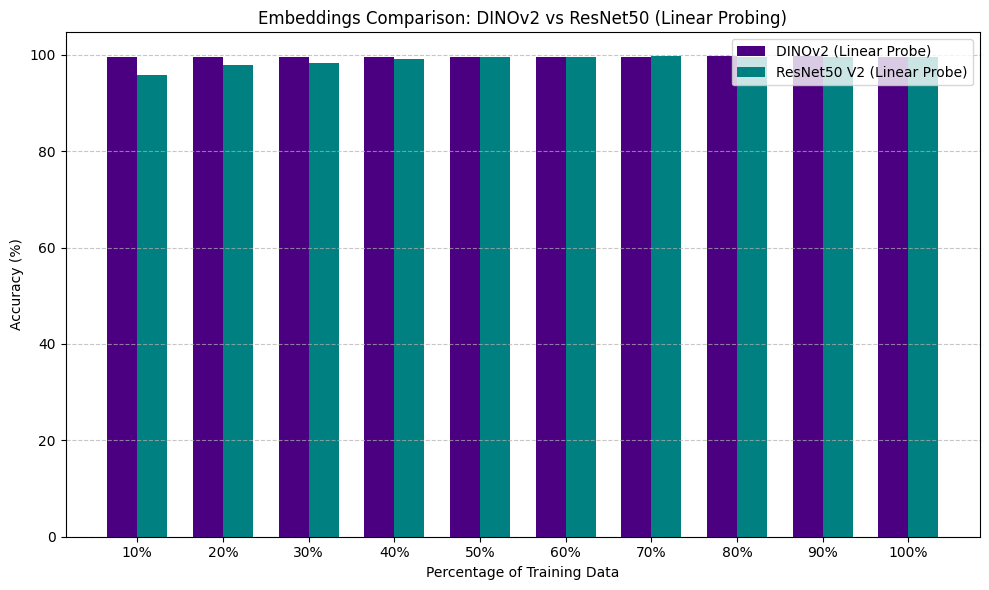

In [15]:
plt.figure(figsize=(10, 6))
x = np.arange(len(percentages))
width = 0.35

plt.bar(x - width / 2, results_dino.values(), width, label='DINOv2 (Linear Probe)', color='indigo')
plt.bar(x + width / 2, results_resnet.values(), width, label='ResNet50 V2 (Linear Probe)', color='teal')

plt.xlabel('Percentage of Training Data')
plt.ylabel('Accuracy (%)')
plt.title('Embeddings Comparison: DINOv2 vs ResNet50 (Linear Probing)')
plt.xticks(x, results_dino.keys())
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Obliczanie PCA dla przestrzeni cech DINO oraz ResNet...
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 160.17it/s]


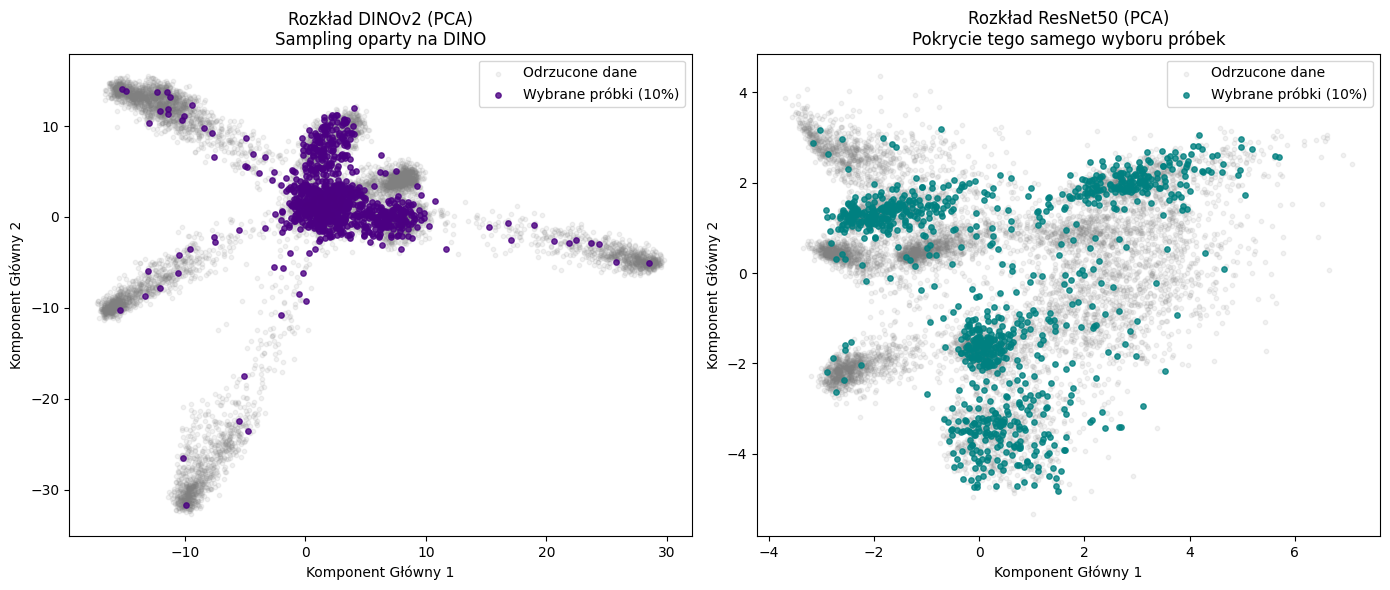

In [16]:
def get_pca_2d(embeddings_tensor):
    emb_mean = embeddings_tensor.mean(dim=0, keepdim=True)
    emb_centered = embeddings_tensor - emb_mean

    U, S, V = torch.pca_lowrank(emb_centered, q=2)

    pca_result = torch.matmul(emb_centered, V[:, :2])
    return pca_result.cpu().numpy()

print("Obliczanie PCA dla przestrzeni cech DINO oraz ResNet...")

dino_pca = get_pca_2d(dino_train_emb.float())
resnet_pca = get_pca_2d(resnet_train_emb.float())

p_vis = 0.1
target_size_vis = int(len(train_dataset) * p_vis)
idx_vis = hs.hierarchical_sampling(cl, target_size=target_size_vis)


selected_mask = np.zeros(len(train_dataset), dtype=bool)
selected_mask[idx_vis] = True


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(dino_pca[~selected_mask, 0], dino_pca[~selected_mask, 1], 
            alpha=0.1, c='gray', label='Odrzucone dane', s=10)
plt.scatter(dino_pca[selected_mask, 0], dino_pca[selected_mask, 1], 
            alpha=0.8, c='indigo', label=f'Wybrane próbki ({int(p_vis*100)}%)', s=15)
plt.title('Rozkład DINOv2 (PCA)\nSampling oparty na DINO')
plt.xlabel('Komponent Główny 1')
plt.ylabel('Komponent Główny 2')
plt.legend()


plt.subplot(1, 2, 2)
plt.scatter(resnet_pca[~selected_mask, 0], resnet_pca[~selected_mask, 1], 
            alpha=0.1, c='gray', label='Odrzucone dane', s=10)
plt.scatter(resnet_pca[selected_mask, 0], resnet_pca[selected_mask, 1], 
            alpha=0.8, c='teal', label=f'Wybrane próbki ({int(p_vis*100)}%)', s=15)
plt.title('Rozkład ResNet50 (PCA)\nPokrycie tego samego wyboru próbek')
plt.xlabel('Komponent Główny 1')
plt.ylabel('Komponent Główny 2')
plt.legend()

plt.tight_layout()
plt.show()

Obliczanie rozkładu klas dla każdego podzbioru...
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 414.88it/s]
Tabela: Rozkład liczby zdjęć w klasach dla każdego wyboru:


Klasa,n01440764,n02102040,n02979186,n03000684,n03028079,n03394916,n03417042,n03425413,n03445777,n03888257
Procent,,,,,,,,,,
10%,13,194,216,12,243,20,200,16,13,19
100%,963,955,993,858,941,956,961,931,951,960
20%,30,387,440,24,474,37,394,28,35,44
30%,46,601,662,32,671,62,610,43,50,63
40%,75,950,714,51,763,110,870,75,78,101
50%,167,955,833,102,913,275,893,186,183,227
60%,265,955,929,159,940,480,907,335,335,376
70%,397,955,993,204,941,699,928,495,509,507
80%,549,955,993,277,941,866,961,694,718,621


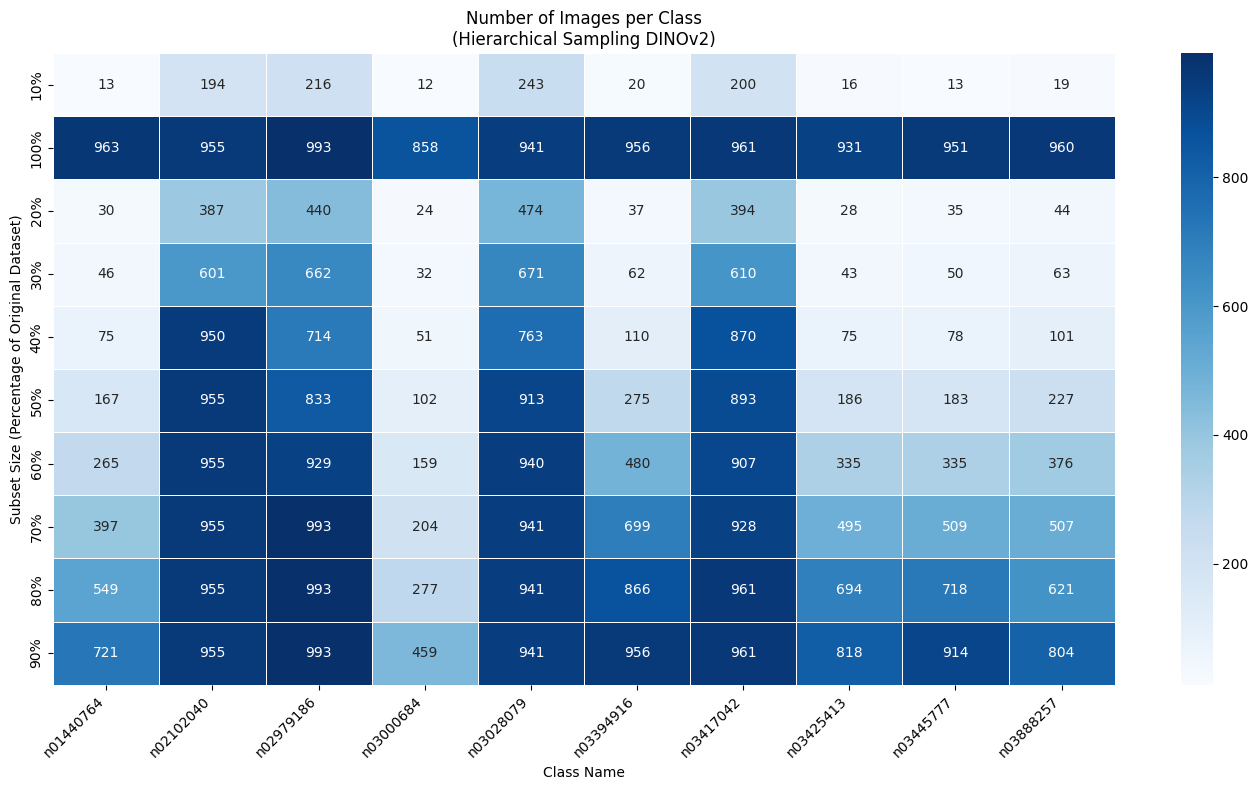

In [17]:
import pandas as pd
import seaborn as sns

class_names = train_dataset.classes if hasattr(train_dataset, 'classes') else [f"Klasa {i}" for i in range(NUM_CLASSES)]

print("Obliczanie rozkładu klas dla każdego podzbioru...")
distribution_data = []
percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for p in percentages:
    target_size = int(len(train_dataset) * p)
    
    if p < 1.0:
        idx = hs.hierarchical_sampling(cl, target_size=target_size)
    else:
        idx = list(range(len(train_dataset)))
    selected_labels = train_labels[idx].numpy()

    unique, counts = np.unique(selected_labels, return_counts=True)
    counts_dict = dict(zip(unique, counts))
    for c in range(NUM_CLASSES):
        distribution_data.append({
            'Procent': f"{int(p*100)}%",
            'Klasa': class_names[c],
            'Liczba próbek': counts_dict.get(c, 0)
        })

df_dist = pd.DataFrame(distribution_data)
pivot_df = df_dist.pivot(index="Procent", columns="Klasa", values="Liczba próbek")


print("Tabela: Rozkład liczby zdjęć w klasach dla każdego wyboru:")
display(pivot_df) 


plt.figure(figsize=(14, 8))
sns.heatmap(pivot_df, annot=True, fmt="d", cmap="Blues", linewidths=.5)
plt.title("Number of Images per Class\n(Hierarchical Sampling DINOv2)")
plt.ylabel("Subset Size (Percentage of Original Dataset)")
plt.xlabel("Class Name")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Badanie równomierności (uniformity) rozkładu klas...
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 828.91it/s]

Tabela z wynikami uniformizacji:


,Procent Danych,Rozmiar Podzbioru,Odchylenie (Std),Zmienność (CV) %,Entropia (0-1)
0,10%,946,97.23,102.78,0.7587
1,20%,1893,196.30,103.70,0.7543
2,30%,2840,287.51,101.24,0.7654
3,40%,3787,368.54,97.32,0.7886
4,50%,4734,350.71,74.08,0.8795
5,60%,5681,307.29,54.09,0.9346
6,70%,6628,264.89,39.96,0.9625
7,80%,7575,219.34,28.96,0.9792
8,90%,8522,154.98,18.19,0.9919
9,100%,9469,33.33,3.52,0.9997


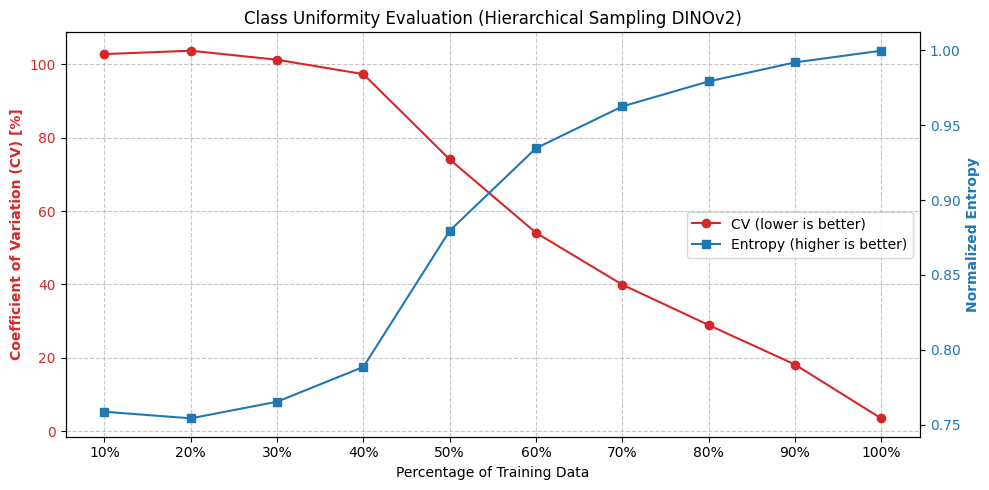

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

print("Badanie równomierności (uniformity) rozkładu klas...")
uniformity_results = []
percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for p in percentages:
    target_size = int(len(train_dataset) * p)
    
    if p < 1.0:
        idx = hs.hierarchical_sampling(cl, target_size=target_size)
    else:
        idx = list(range(len(train_dataset)))
        
    selected_labels = train_labels[idx].numpy()
    
    counts = np.bincount(selected_labels, minlength=NUM_CLASSES)
    

    std_dev = np.std(counts)
    mean_count = np.mean(counts)
    cv = (std_dev / mean_count) * 100 if mean_count > 0 else 0
    
    probs = counts / np.sum(counts)
    norm_entropy = entropy(probs) / np.log(NUM_CLASSES)
    
    uniformity_results.append({
        'Procent Danych': f"{int(p*100)}%",
        'Rozmiar Podzbioru': target_size,
        'Odchylenie (Std)': round(std_dev, 2),
        'Zmienność (CV) %': round(cv, 2),
        'Entropia (0-1)': round(norm_entropy, 4)
    })


df_uniformity = pd.DataFrame(uniformity_results)
print("\nTabela z wynikami uniformizacji:")
display(df_uniformity)

fig, ax1 = plt.subplots(figsize=(10, 5))


ax1.set_xlabel('Percentage of Training Data')
ax1.set_ylabel('Coefficient of Variation (CV) [%]', color='tab:red', fontweight='bold')
line1 = ax1.plot(df_uniformity['Procent Danych'], df_uniformity['Zmienność (CV) %'], 
                 marker='o', color='tab:red', label='CV (lower is better)')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()  
ax2.set_ylabel('Normalized Entropy', color='tab:blue', fontweight='bold')
line2 = ax2.plot(df_uniformity['Procent Danych'], df_uniformity['Entropia (0-1)'], 
                 marker='s', color='tab:blue', label='Entropy (higher is better)')
ax2.tick_params(axis='y', labelcolor='tab:blue')


lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Class Uniformity Evaluation (Hierarchical Sampling DINOv2)')
ax1.grid(True, linestyle='--', alpha=0.7)
fig.tight_layout()
plt.show()